# Chromosome X Replicate 1 - Prototype Replication Deconvolution

In [21]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

config, _ = load_default_chrom_configs()

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


###### 

In [24]:
real_deconv1.config.alpha = 0
# real_deconv1.config.params_dic.update({
#  'mu0': 5.95086178727135,
#  'delta': 8.5420424946663758,
#  'sigma0': 4.574125731433994,
#  'sigmav': 0.1041649693276692,
#  'lambda': 65.82132480815547,
#  'gamma1': 0.4618683933074595,
#  'gamma2': 0.6961471064538352,
#  'halted': 1.030819214491829e-06,
#  'alpha': 0})

real_deconv1.config.update_timepoints()
real_deconv1.config.calculate_H()
real_deconv1.config.params_dic

# How will the fit look, if we initialized with the parameters from CLOCCS?

{'mu0': -26.7901,
 'delta': 8.1805,
 'sigma0': 10.9885,
 'sigmav': 0.1424,
 'lambda': 68.1914,
 'gamma1': 0.0041,
 'gamma2': 0.2547,
 'halted': 0.2245,
 'alpha': 0}

In [25]:
real_deconv1.setup_deconvolution(real_deconv1.config)
real_deconv1.iterative_deconvolution_updates(1)

Initializing N using config H.
Initializing B using timepoint 0
Iteration 0
0/339 - 00:00:00.001
100/339 - 00:00:00.025
200/339 - 00:00:00.047
300/339 - 00:00:00.069
Iteration completed 00:00:00.102, rn=0.008385365285412092


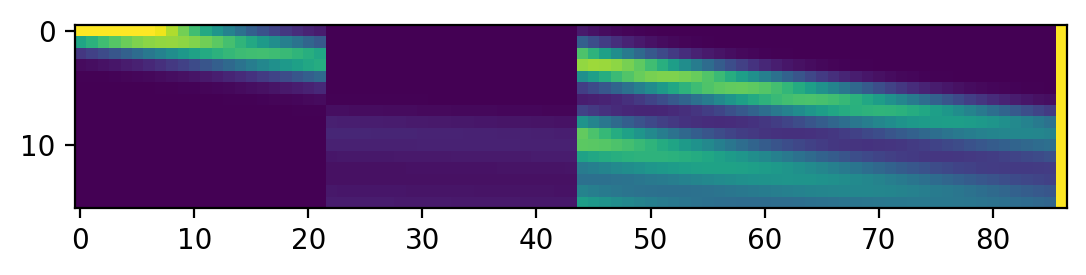

In [26]:
plt.imshow(real_deconv1.config.H, vmax=0.05)

In [27]:
from src.optimize_H import ParameterOptimizer

In [28]:
timepoints = config.timepoints
initial_values = config.params_dic

init_params_df = pd.DataFrame(initial_values, index=['value']).T
init_params_df = init_params_df.drop('alpha')
init_params_df

,value
mu0,-26.7901
delta,8.1805
sigma0,10.9885
sigmav,0.1424
lambda,68.1914
gamma1,0.0041
gamma2,0.2547
halted,0.2245


In [29]:
bounds_dic = {
    'mu0': (-30, 30),
    'lambda': (60, 80),
    'delta': (0, 14),
    'sigma0': (1, 14),
    'sigmav': (0.01, 1.),
    'gamma1': (0., 1.),
    'gamma2': (0., 1.),
    'halted': (0.0, 1.),
}

bounds_params_df = pd.DataFrame(bounds_dic, index=['min', 'max']).T
params_df = init_params_df.join(bounds_params_df)
params_df


,value,min,max
mu0,-26.7901,-30.00,30.0
delta,8.1805,0.00,14.0
sigma0,10.9885,1.00,14.0
sigmav,0.1424,0.01,1.0
lambda,68.1914,60.00,80.0
gamma1,0.0041,0.00,1.0
gamma2,0.2547,0.00,1.0
halted,0.2245,0.00,1.0


In [30]:
real_deconv1.setup_deconvolution(real_deconv1.config)

Initializing N using config H.
Initializing B using timepoint 0


In [31]:
real_deconv1.iterative_deconvolution_updates(20)

Iteration 0
0/339 - 00:00:00.007
100/339 - 00:00:00.037
200/339 - 00:00:00.065
300/339 - 00:00:00.089
Iteration completed 00:00:00.153, rn=0.008385365285412092
Iteration 1
0/339 - 00:00:00.154
100/339 - 00:00:00.176
200/339 - 00:00:00.198
300/339 - 00:00:00.221
Iteration completed 00:00:00.322, rn=0.0050482307000107125
Iteration 2
0/339 - 00:00:00.324
100/339 - 00:00:00.345
200/339 - 00:00:00.368
300/339 - 00:00:00.390
Iteration completed 00:00:00.470, rn=0.004724594070240545
Iteration 3
0/339 - 00:00:00.472
100/339 - 00:00:00.494
200/339 - 00:00:00.516
300/339 - 00:00:00.539
Iteration completed 00:00:00.637, rn=0.004597790422245275
Iteration 4
0/339 - 00:00:00.639
100/339 - 00:00:00.661
200/339 - 00:00:00.683
300/339 - 00:00:00.705
Iteration completed 00:00:00.737, rn=0.004550526888655757
Iteration 5
0/339 - 00:00:00.738
100/339 - 00:00:00.760
200/339 - 00:00:00.783
300/339 - 00:00:00.805
Iteration completed 00:00:00.865, rn=0.004537333405274313
Iteration 6
0/339 - 00:00:00.866
100/33

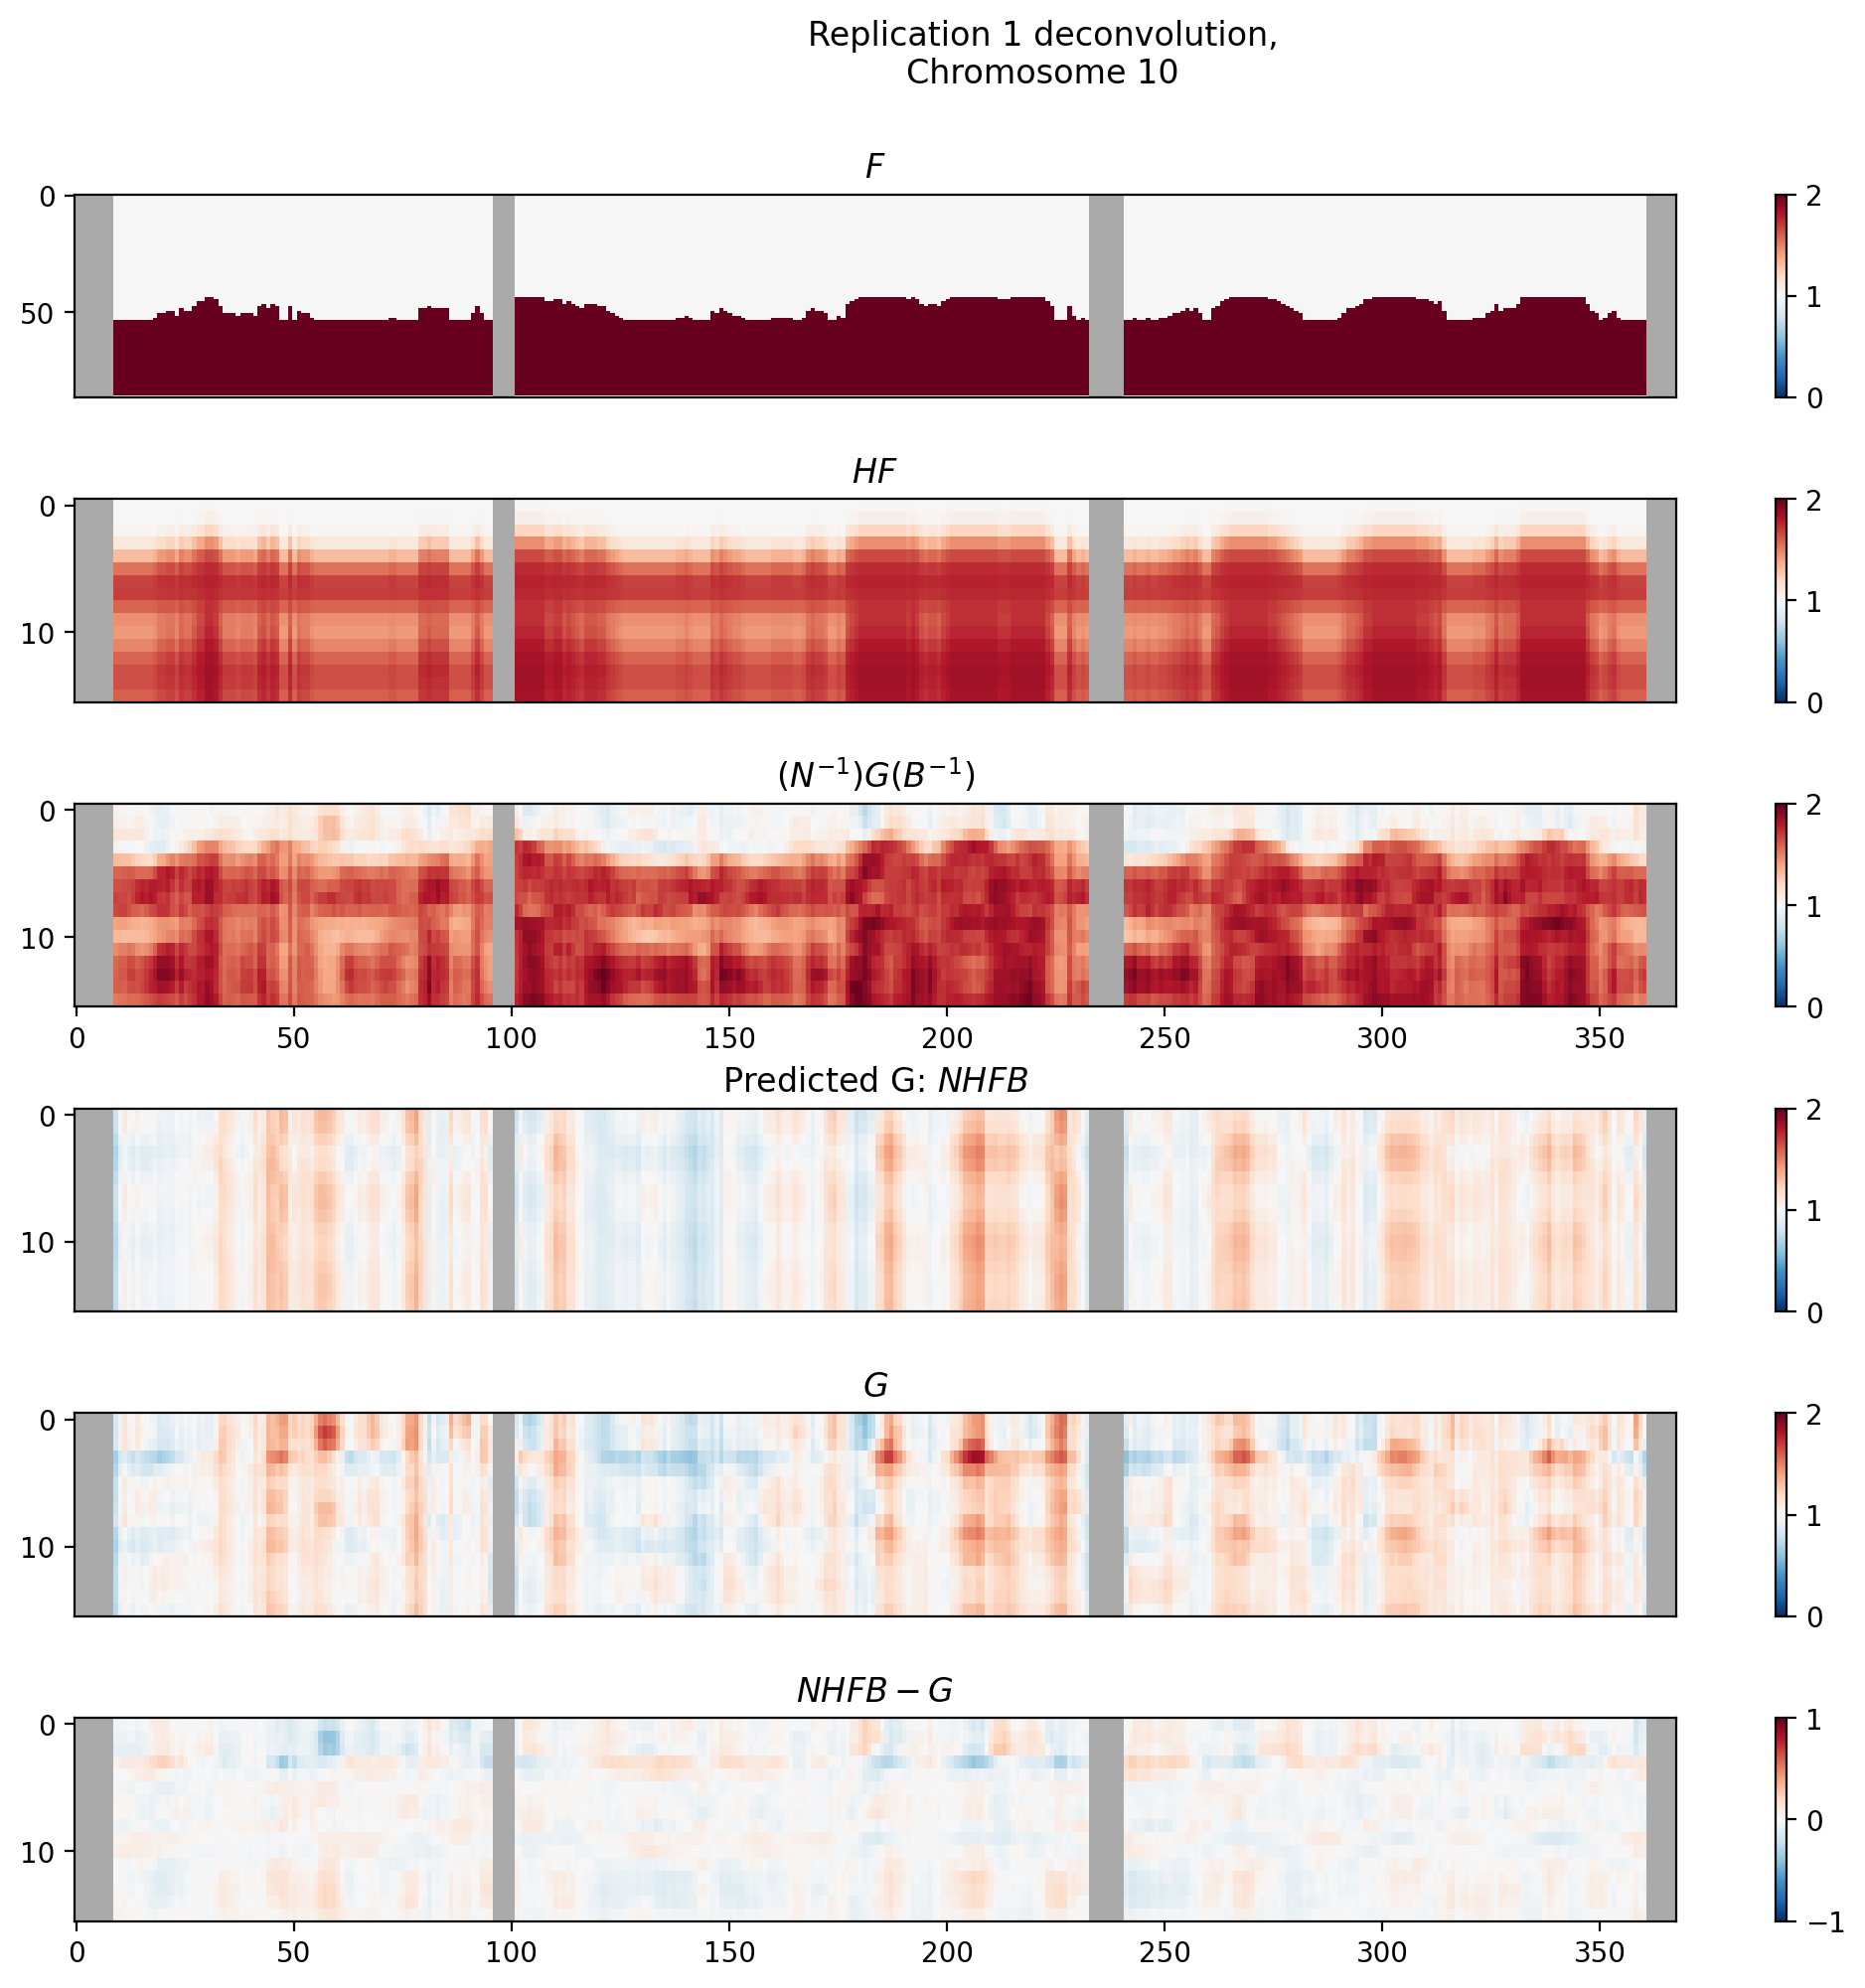

In [32]:
real_deconv1.plot_heatmaps()

In [33]:
optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)


In [ ]:
from src.timer import Timer
from src.single_G1_config import calcH

timer = Timer()

num_epochs = 200
num_iterations_N_B = 5
update_params_df = pd.DataFrame()

N = real_deconv1.N
B = real_deconv1.B

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    
    optimizer.optimize(maxiter=1000, verbose=True)

    real_deconv1.H = optimizer.current_H
        
    real_deconv1.iterative_deconvolution_updates(
        total_iterations=num_iterations_N_B, timer=timer,
        initial_B=B, initial_N=N)
    timer.print_time()
    
    params_row = pd.DataFrame([optimizer.params_df['value']], index=[epoch])
    params_row['opt_H_loss'] = optimizer.rn
    params_row['F_rn'] = real_deconv1.rn

    update_params_df = pd.concat([update_params_df, params_row])
    
    optimizer.N = real_deconv1.N
    optimizer.B = real_deconv1.B
    optimizer.F = real_deconv1.F
    
    N = real_deconv1.N
    B = real_deconv1.B

    print(update_params_df.iloc[-1])


Epoch:  0
Optimization [1]: Current loss: 0.004533318745201683
Optimization [101]: Current loss: 0.0043179041768942935
Optimization [201]: Current loss: 0.004294448053431834
Optimization [301]: Current loss: 0.00429345151177696
Optimization terminated successfully.
         Current function value: 0.004293
         Iterations: 207
         Function evaluations: 319
Iteration 0
0/339 - 00:01:08.461
100/339 - 00:01:08.489
200/339 - 00:01:08.517
300/339 - 00:01:08.545
Iteration completed 00:01:08.616, rn=0.004201149780149963
Iteration 1
0/339 - 00:01:08.617
100/339 - 00:01:08.644
200/339 - 00:01:08.670
300/339 - 00:01:08.697
Iteration completed 00:01:09.068, rn=0.003955951309044495
Iteration 2
0/339 - 00:01:09.070
100/339 - 00:01:09.096
200/339 - 00:01:09.121
300/339 - 00:01:09.148
Iteration completed 00:01:09.461, rn=0.003921636933031592
Iteration 3
0/339 - 00:01:09.462
100/339 - 00:01:09.487
200/339 - 00:01:09.513
300/339 - 00:01:09.538
Iteration completed 00:01:09.624, rn=0.00391155611

100/339 - 00:07:42.660
200/339 - 00:07:42.666
300/339 - 00:07:42.673
Iteration completed 00:07:42.737, rn=0.005979938281875238
00:07:42.737
mu0          -22.765898
lambda        74.851768
delta          4.321551
sigma0         1.852567
sigmav         0.174784
gamma1         0.008081
gamma2         0.058084
halted         0.282435
opt_H_loss     0.006040
F_rn           0.005980
Name: 5, dtype: float64
Epoch:  6
Optimization [1]: Current loss: 0.005979938281875241
Optimization [101]: Current loss: 0.005950081357367314
Optimization [201]: Current loss: 0.005949570454988945
Optimization [301]: Current loss: 0.005949486437547977
Optimization terminated successfully.
         Current function value: 0.005949
         Iterations: 243
         Function evaluations: 368
Iteration 0
0/339 - 00:08:58.790
100/339 - 00:08:58.797
200/339 - 00:08:58.804
300/339 - 00:08:58.811
Iteration completed 00:08:59.203, rn=0.005945432052112539
Iteration 1
0/339 - 00:08:59.204
100/339 - 00:08:59.211
200/339 - 00

Iteration completed 00:14:33.545, rn=0.004663343326645999
Iteration 2
0/339 - 00:14:33.547
100/339 - 00:14:33.557
200/339 - 00:14:33.568
300/339 - 00:14:33.579
Iteration completed 00:14:34.043, rn=0.004665208648601878
Iteration 3
0/339 - 00:14:34.044
100/339 - 00:14:34.055
200/339 - 00:14:34.066
300/339 - 00:14:34.077
Iteration completed 00:14:34.397, rn=0.004665214033823358
Iteration 4
0/339 - 00:14:34.399
100/339 - 00:14:34.410
200/339 - 00:14:34.421
300/339 - 00:14:34.432
Iteration completed 00:14:34.642, rn=0.004665214027077009
00:14:34.645
mu0          -24.707238
lambda        70.832510
delta          7.332393
sigma0         1.618535
sigmav         0.130816
gamma1         0.000004
gamma2         0.116644
halted         0.253527
opt_H_loss     0.004416
F_rn           0.004665
Name: 11, dtype: float64
Epoch:  12
Optimization [1]: Current loss: 0.004665214027077007
Optimization [101]: Current loss: 0.0046510989577744615
Optimization [201]: Current loss: 0.004649236812282851
Optimizat

100/339 - 00:20:58.283
200/339 - 00:20:58.299
300/339 - 00:20:58.315
Iteration completed 00:20:58.600, rn=0.004093979175869089
Iteration 1
0/339 - 00:20:58.603
100/339 - 00:20:58.627
200/339 - 00:20:58.643
300/339 - 00:20:58.662
Iteration completed 00:20:58.882, rn=0.004068909957347194
Iteration 2
0/339 - 00:20:58.883
100/339 - 00:20:58.899
200/339 - 00:20:58.915
300/339 - 00:20:58.931
Iteration completed 00:20:59.303, rn=0.004064564090729767
Iteration 3
0/339 - 00:20:59.304
100/339 - 00:20:59.327
200/339 - 00:20:59.344
300/339 - 00:20:59.365
Iteration completed 00:20:59.584, rn=0.004064536328389654
Iteration 4
0/339 - 00:20:59.585
100/339 - 00:20:59.600
200/339 - 00:20:59.615
300/339 - 00:20:59.630
Iteration completed 00:20:59.969, rn=0.0040645363446488725
00:20:59.969
mu0          -25.477426
lambda        67.813577
delta          7.834128
sigma0         2.324573
sigmav         0.109314
gamma1         0.000006
gamma2         0.160817
halted         0.234191
opt_H_loss     0.004096
F_r

200/339 - 00:24:26.650
300/339 - 00:24:26.666
Iteration completed 00:24:26.993, rn=0.004007214688837397
Iteration 2
0/339 - 00:24:26.994
100/339 - 00:24:27.008
200/339 - 00:24:27.023
300/339 - 00:24:27.037
Iteration completed 00:24:27.598, rn=0.004007207338928363
Iteration 3
0/339 - 00:24:27.599
100/339 - 00:24:27.614
200/339 - 00:24:27.628
300/339 - 00:24:27.643
Iteration completed 00:24:28.004, rn=0.0040072073355983725
Iteration 4
0/339 - 00:24:28.005
100/339 - 00:24:28.020
200/339 - 00:24:28.034
300/339 - 00:24:28.049
Iteration completed 00:24:28.541, rn=0.004007207335597089
00:24:28.541
mu0          -25.950298
lambda        66.410374
delta          8.843630
sigma0         2.956879
sigmav         0.107791
gamma1         0.000007
gamma2         0.153098
halted         0.211823
opt_H_loss     0.004011
F_rn           0.004007
Name: 23, dtype: float64
Epoch:  24
Optimization [1]: Current loss: 0.004007207335597088
Optimization [101]: Current loss: 0.004006369104796021
Optimization termi

...

100/339 - 01:04:03.383
200/339 - 01:04:03.398
300/339 - 01:04:03.412
Iteration completed 01:04:03.746, rn=0.004019317420216128
Iteration 3
0/339 - 01:04:03.747
100/339 - 01:04:03.762
200/339 - 01:04:03.777
300/339 - 01:04:03.791
Iteration completed 01:04:04.001, rn=0.004019339419551433
Iteration 4
0/339 - 01:04:04.002
100/339 - 01:04:04.016
200/339 - 01:04:04.031
300/339 - 01:04:04.045
Iteration completed 01:04:04.272, rn=0.004019339424760287
01:04:04.272
mu0          -25.782953
lambda        65.244165
delta         14.000000
sigma0         3.868634
sigmav         0.127553
gamma1         0.000020
gamma2         0.165335
halted         0.078475
opt_H_loss     0.003841
F_rn           0.004019
Name: 110, dtype: float64
Epoch:  111
Optimization [1]: Current loss: 0.004019339424760285
Optimization [101]: Current loss: 0.004014188359370392
Optimization terminated successfully.
         Current function value: 0.004014
         Iterations: 105
         Function evaluations: 168
Iteration 0
0/

100/339 - 01:07:23.434
200/339 - 01:07:23.452
300/339 - 01:07:23.469
Iteration completed 01:07:23.936, rn=0.003851211676352255
Iteration 4
0/339 - 01:07:23.938
100/339 - 01:07:23.954
200/339 - 01:07:23.971
300/339 - 01:07:23.988
Iteration completed 01:07:24.148, rn=0.003851211676351282
01:07:24.148
mu0          -25.684690
lambda        65.776931
delta         14.000000
sigma0         3.686317
sigmav         0.131526
gamma1         0.000022
gamma2         0.173489
halted         0.070495
opt_H_loss     0.003852
F_rn           0.003851
Name: 116, dtype: float64
Epoch:  117
Optimization [1]: Current loss: 0.003851211676351281
Optimization [101]: Current loss: 0.0038509288947538235
Optimization terminated successfully.
         Current function value: 0.003851
         Iterations: 57
         Function evaluations: 105
Iteration 0
0/339 - 01:07:46.139
100/339 - 01:07:46.156
200/339 - 01:07:46.172
300/339 - 01:07:46.189
Iteration completed 01:07:46.743, rn=0.003850929047388075
Iteration 1
0/

100/339 - 01:10:31.274
200/339 - 01:10:31.299
300/339 - 01:10:31.318
Iteration completed 01:10:31.530, rn=0.004033791841723752
01:10:31.530
mu0          -25.424963
lambda        66.563528
delta         14.000000
sigma0         2.824308
sigmav         0.137184
gamma1         0.000025
gamma2         0.145039
halted         0.065216
opt_H_loss     0.004254
F_rn           0.004034
Name: 122, dtype: float64
Epoch:  123
Optimization [1]: Current loss: 0.004033791841723751
Optimization [101]: Current loss: 0.004032349700053156
Optimization terminated successfully.
         Current function value: 0.004032
         Iterations: 68
         Function evaluations: 124
Iteration 0
0/339 - 01:10:57.965
100/339 - 01:10:57.980
200/339 - 01:10:57.994
300/339 - 01:10:58.009
Iteration completed 01:10:58.333, rn=0.004032254887120272
Iteration 1
0/339 - 01:10:58.334
100/339 - 01:10:58.349
200/339 - 01:10:58.363
300/339 - 01:10:58.378
Iteration completed 01:10:58.824, rn=0.004034215196410786
Iteration 2
0/3

Optimization [1]: Current loss: 0.004050737251353442
Optimization [101]: Current loss: 0.0040501097835133806
Optimization terminated successfully.
         Current function value: 0.004050
         Iterations: 70
         Function evaluations: 127
Iteration 0
0/339 - 01:14:03.682
100/339 - 01:14:03.697
200/339 - 01:14:03.712
300/339 - 01:14:03.727
Iteration completed 01:14:03.965, rn=0.004050080831654784
Iteration 1
0/339 - 01:14:03.966
100/339 - 01:14:03.980
200/339 - 01:14:03.995
300/339 - 01:14:04.009
Iteration completed 01:14:04.228, rn=0.004053208255285524
Iteration 2
0/339 - 01:14:04.229
100/339 - 01:14:04.244
200/339 - 01:14:04.258
300/339 - 01:14:04.273
Iteration completed 01:14:04.698, rn=0.004053196720987431
Iteration 3
0/339 - 01:14:04.699
100/339 - 01:14:04.714
200/339 - 01:14:04.729
300/339 - 01:14:04.743
Iteration completed 01:14:05.032, rn=0.004053196716487084
Iteration 4
0/339 - 01:14:05.034
100/339 - 01:14:05.048
200/339 - 01:14:05.063
300/339 - 01:14:05.078
Iteration 

100/339 - 01:16:52.559
200/339 - 01:16:52.573
300/339 - 01:16:52.588
Iteration completed 01:16:52.934, rn=0.00406351488363795
Iteration 1
0/339 - 01:16:52.935
100/339 - 01:16:52.950
200/339 - 01:16:52.968
300/339 - 01:16:52.983
Iteration completed 01:16:53.477, rn=0.004066151538199051
Iteration 2
0/339 - 01:16:53.479
100/339 - 01:16:53.494
200/339 - 01:16:53.508
300/339 - 01:16:53.523
Iteration completed 01:16:53.921, rn=0.0040661399012635845
Iteration 3
0/339 - 01:16:53.922
100/339 - 01:16:53.937
200/339 - 01:16:53.952
300/339 - 01:16:53.966
Iteration completed 01:16:54.554, rn=0.004066139896824307
Iteration 4
0/339 - 01:16:54.556
100/339 - 01:16:54.570
200/339 - 01:16:54.584
300/339 - 01:16:54.598
Iteration completed 01:16:54.837, rn=0.004066139896822669
01:16:54.837
mu0          -25.127089
lambda        68.487803
delta         14.000000
sigma0         2.581984
sigmav         0.150248
gamma1         0.000031
gamma2         0.159223
halted         0.045413
opt_H_loss     0.004064
F_rn

Text(0.5, 0.98, 'Cell cycle parameter updates, 200 epochs')

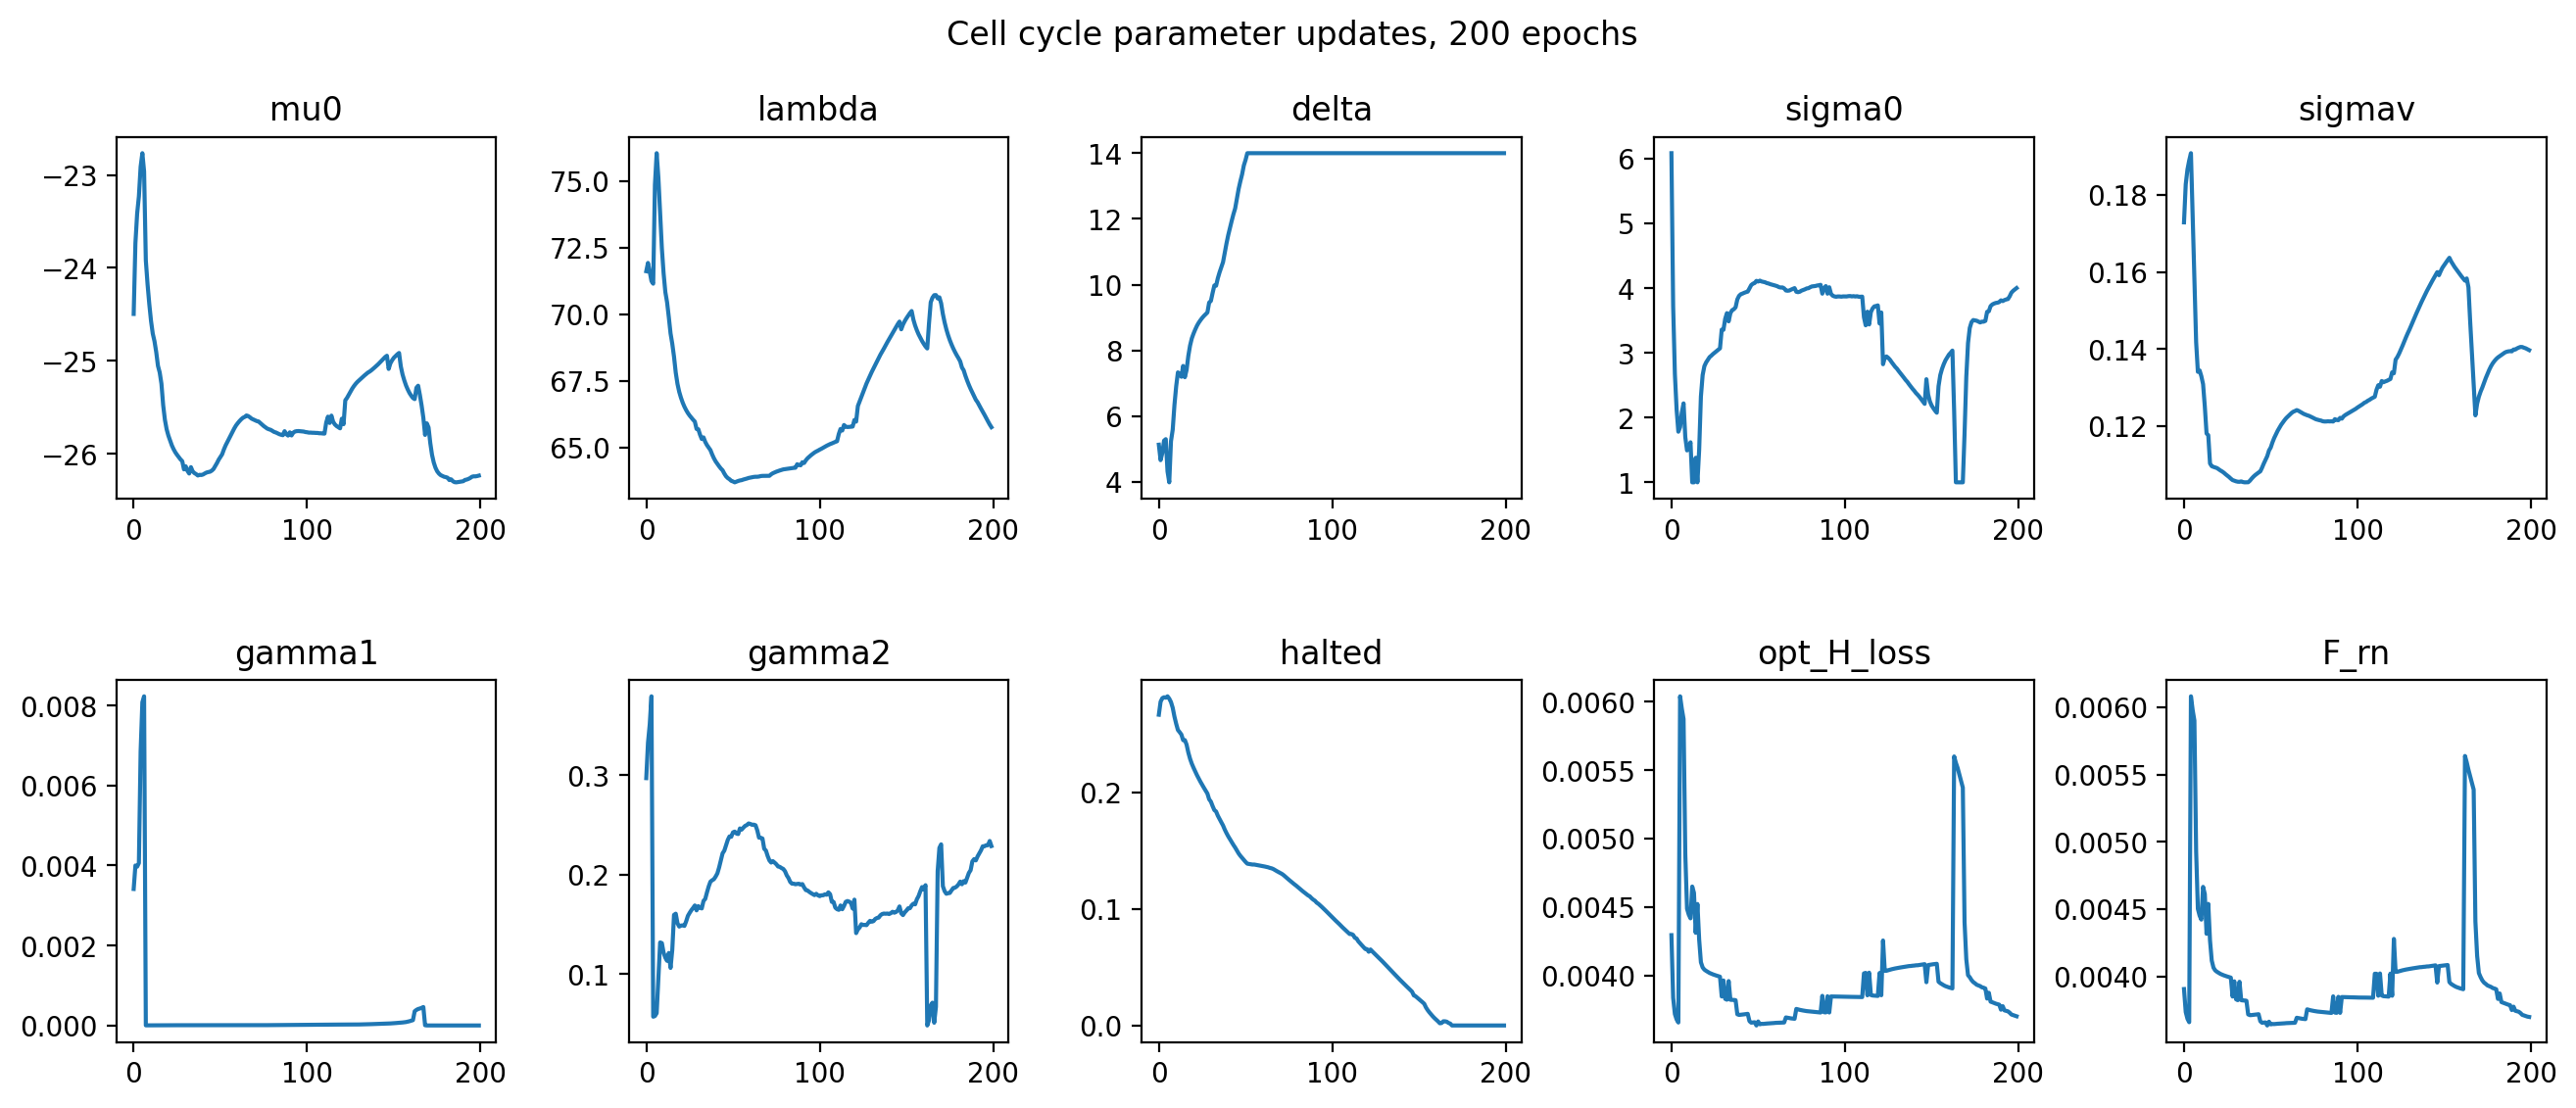

In [35]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

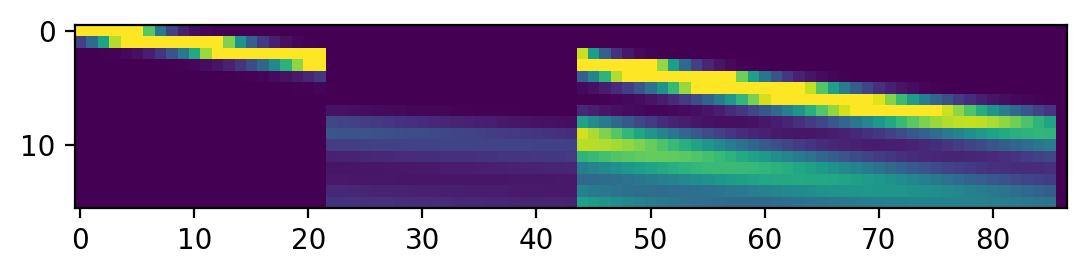

In [36]:
plt.imshow(real_deconv1.H, vmax=0.05)

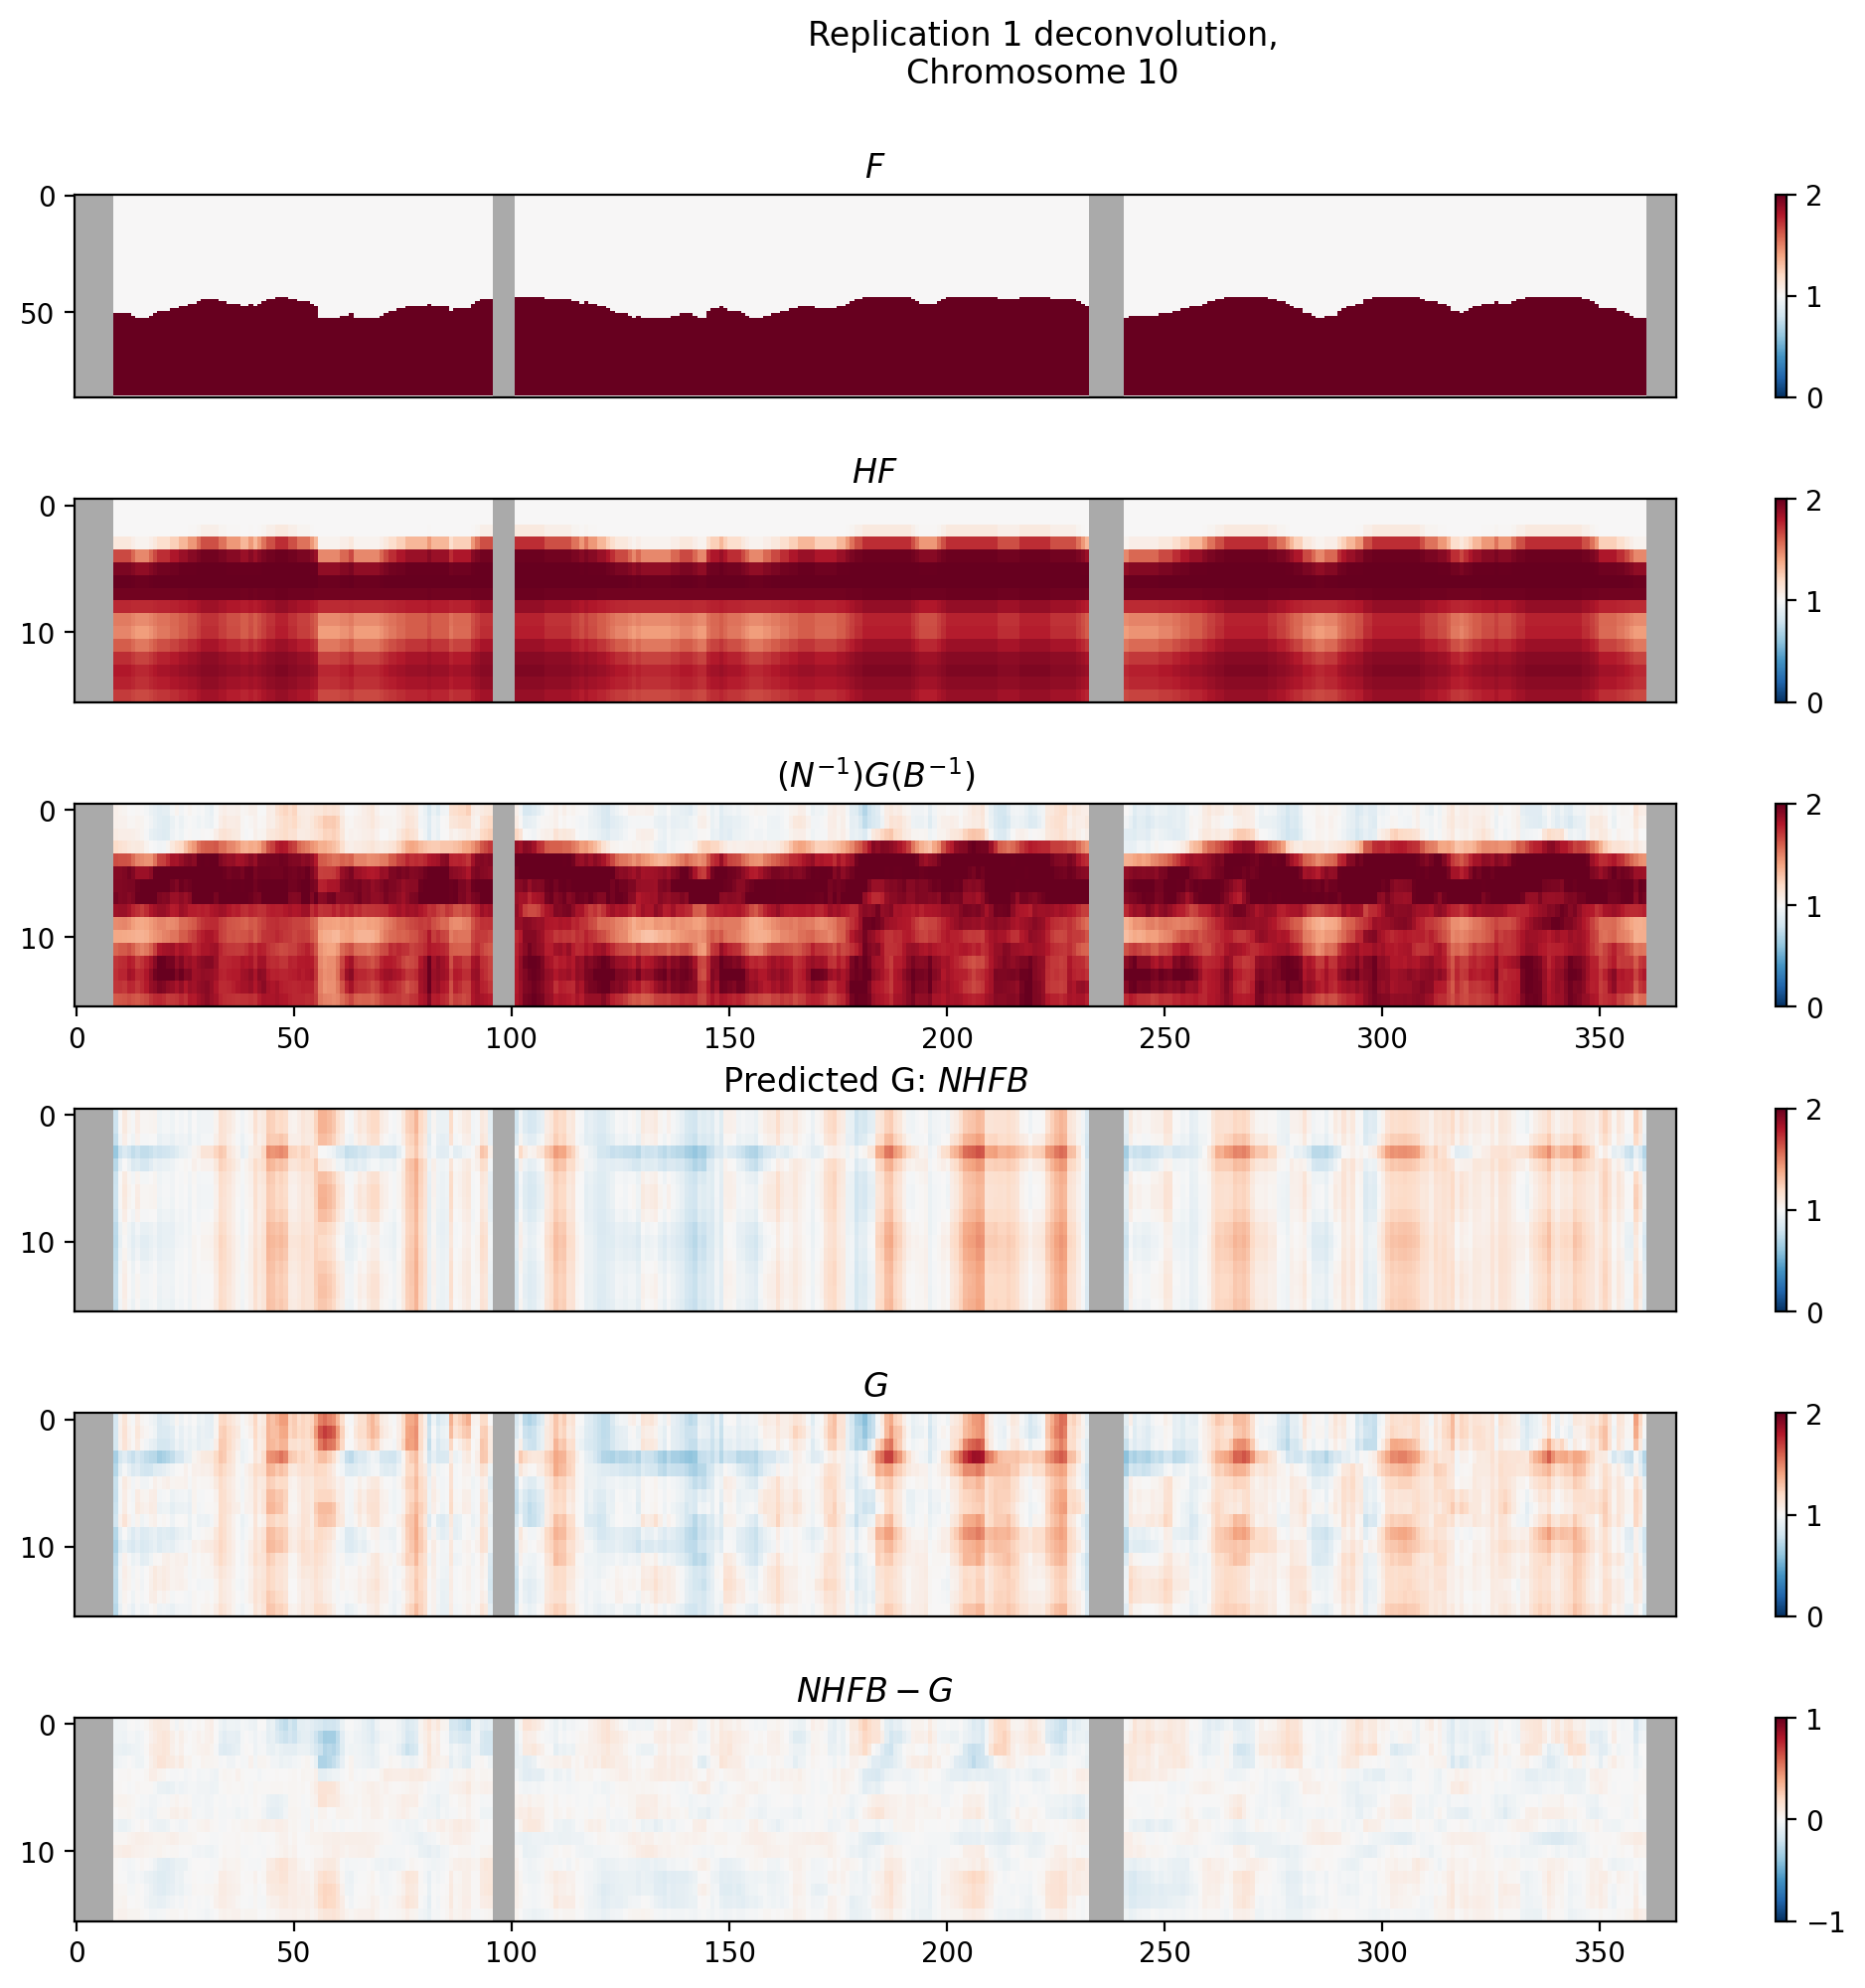

In [37]:
real_deconv1.plot_heatmaps()

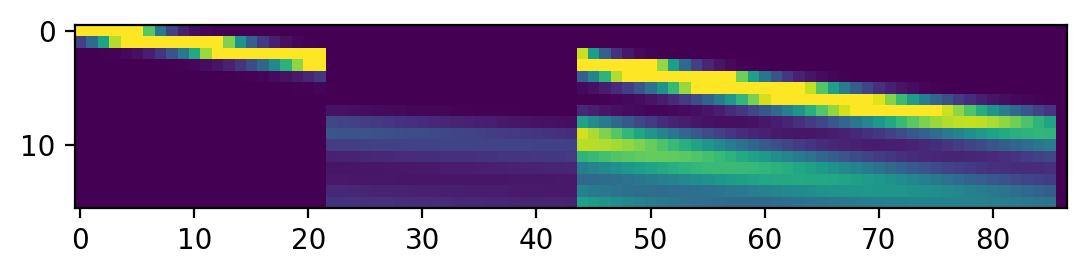

In [38]:
plt.imshow(config.H, vmax=0.05)

In [39]:
config.params_dic

{'mu0': -26.235058081606713,
 'delta': 14.0,
 'sigma0': 4.0008500184247024,
 'sigmav': 0.13966478664563142,
 'lambda': 65.76970249526265,
 'gamma1': 3.3249264453890173e-07,
 'gamma2': 0.22867660032518647,
 'halted': 1.4912894399140285e-06,
 'alpha': 0}

In [20]:
# Old non-CLOCCS initialization fits.. for comparison
# Hope is that initialization won't matter too much and we will converge to the same values
# of mu0, gamma1, gamm2, etc...

config.params_dic

{'mu0': 25.949932608260184,
 'delta': 0.01025928566958726,
 'sigma0': 4.78583475128696,
 'sigmav': 0.10142629338693973,
 'lambda': 66.94569749620106,
 'gamma1': 0.7568772504524719,
 'gamma2': 1.0,
 'halted': 1.947631245254337e-06,
 'alpha': 0}